# TP1: Signal procesing
## Autor: Volodya ALEKSANYAN

## Data

A guitar note is not a pure sine: it has a fundamental frequency plus harmonics. We want the fundamental, which is the pitch we hear.

## Plan

1. Load each `.wav` file.
2. Plot the waveform.
3. Compute the FFT magnitude spectrum.
4. Find the fundamental frequency and match it to the closest guitar note, with the deviation in cents.

## Setup

In [1]:
import numpy as np
from scipy.io import wavfile
from scipy.fft import fft, fftfreq, fftshift
import matplotlib.pyplot as plt

# Theoretical guitar note frequencies (Hz)
NOTE_FREQS = {
    "E1": 329.63,
    "B2": 246.94,
    "G3": 196.00,
    "D4": 146.83,
    "A5": 110.00,
    "E6": 82.41,
}

# "1 cent" value in Hz for each note above (how many Hz a 1-cent deviation represents)
ONE_CENT_HZ = {
    "E1": 0.15,
    "B2": 0.15,
    "G3": 0.15,
    "D4": 0.08,
    "A5": 0.08,
    "E6": 0.04,
}

FILES = ["../data/string_1.wav", "../data/string_2.wav", "../data/string_3.wav"]

## Load the recordings

In [2]:
signals = {}

for f in FILES:
    sr, data = wavfile.read(f)
    data = data.astype(np.float64) / 32768.0
    signals[f] = (sr, data)
    print(f"{f}: sample rate = {sr} Hz, duration = {len(data) / sr:.2f} s")

../data/string_1.wav: sample rate = 44100 Hz, duration = 5.39 s
../data/string_2.wav: sample rate = 22050 Hz, duration = 5.35 s
../data/string_3.wav: sample rate = 22050 Hz, duration = 5.64 s


## Visualize the waveforms

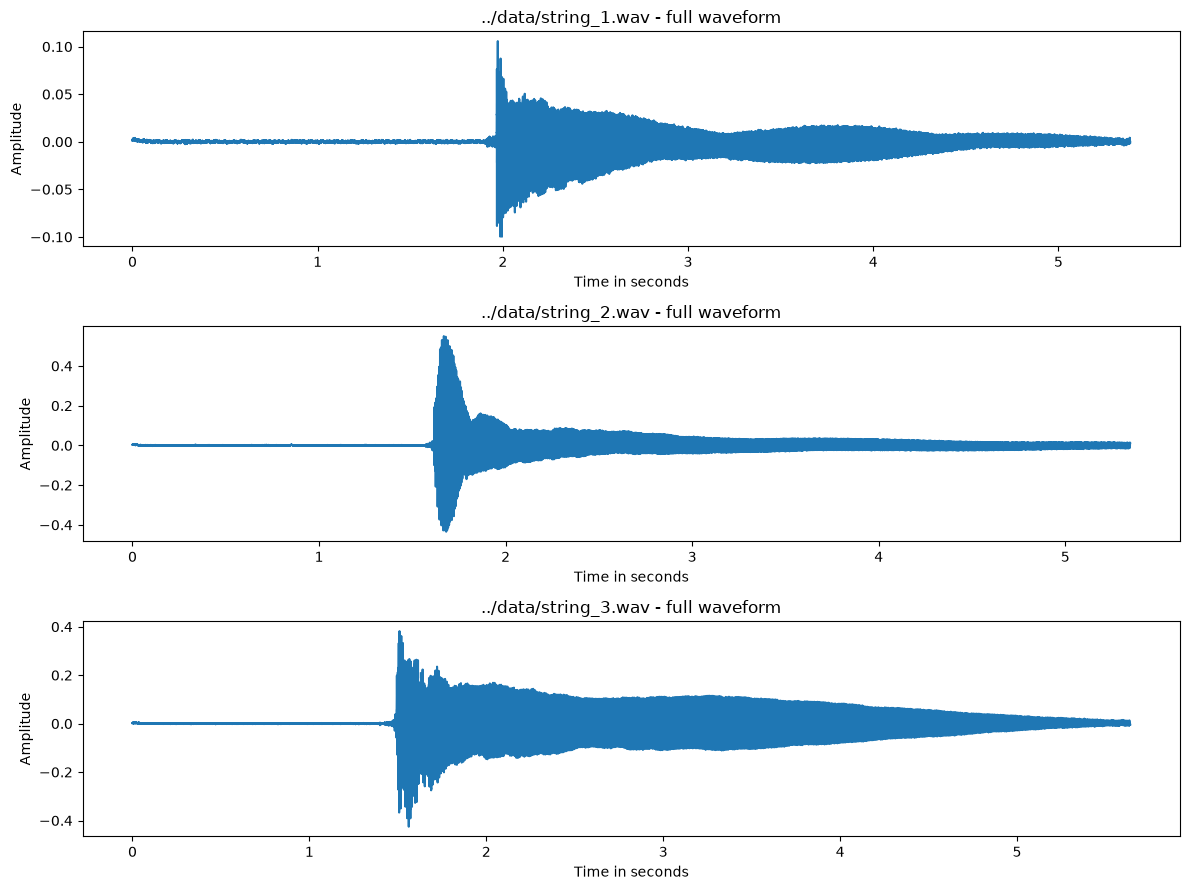

In [3]:
fig, axes = plt.subplots(len(FILES), figsize=(12, 3 * len(FILES)))

for i, f in enumerate(FILES):
    sr, data = signals[f]
    t = np.arange(len(data)) / sr

    axes[i].plot(t, data)
    axes[i].set_title(f"{f} - full waveform")
    axes[i].set_xlabel("Time in seconds")
    axes[i].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Spectral analysis

We compute the FFT magnitude spectrum. fft.fft gives frequencies like [0 ... +max, -max ... 0], thus we use fftshift to reorder them from negative to positive before plotting. We would also plot only the positive ones as they give the same information as the negative ones... *:)*

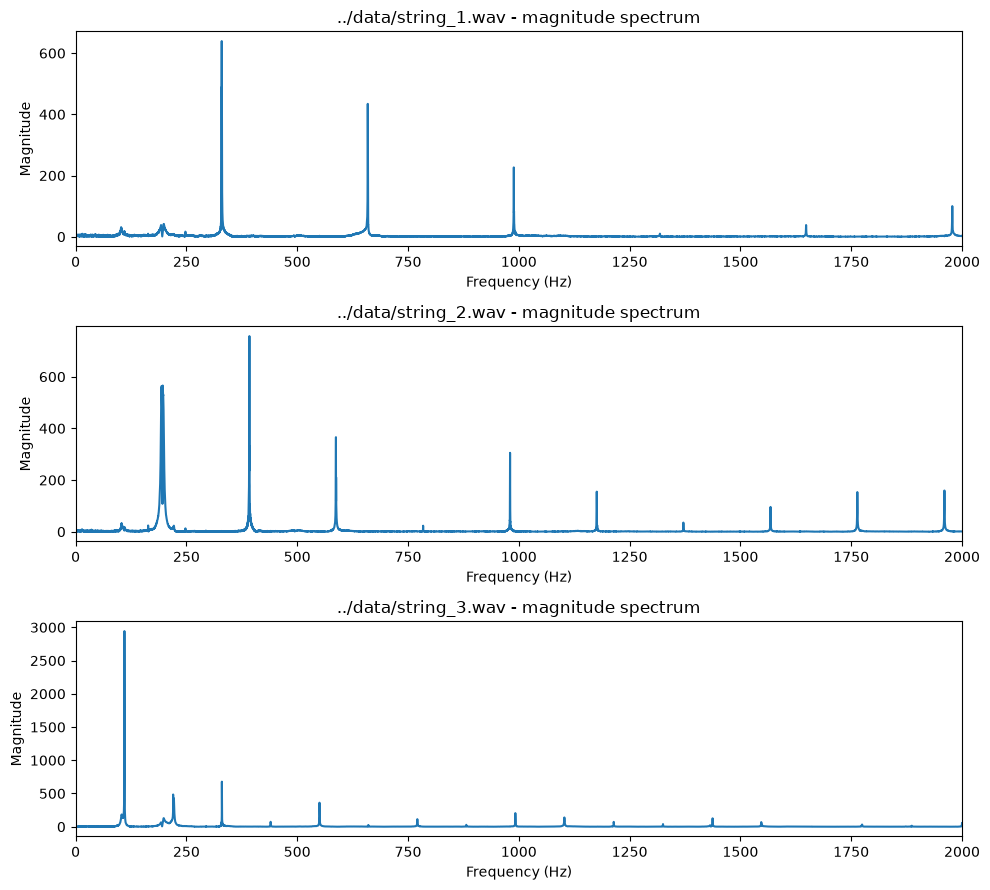

In [4]:
spectra = {}

fig, axes = plt.subplots(len(FILES), 1, figsize=(10, 3 * len(FILES)))

for i, f in enumerate(FILES):
    sr, data = signals[f]

    spectrum = np.abs(fftshift(fft(data)))
    freqs = fftshift(fftfreq(len(data), 1 / sr))
    spectra[f] = (freqs, spectrum)

    axes[i].plot(freqs, spectrum)
    axes[i].set_xlim(0, 2000)
    axes[i].set_title(f"{f} - magnitude spectrum")
    axes[i].set_xlabel("Frequency (Hz)")
    axes[i].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

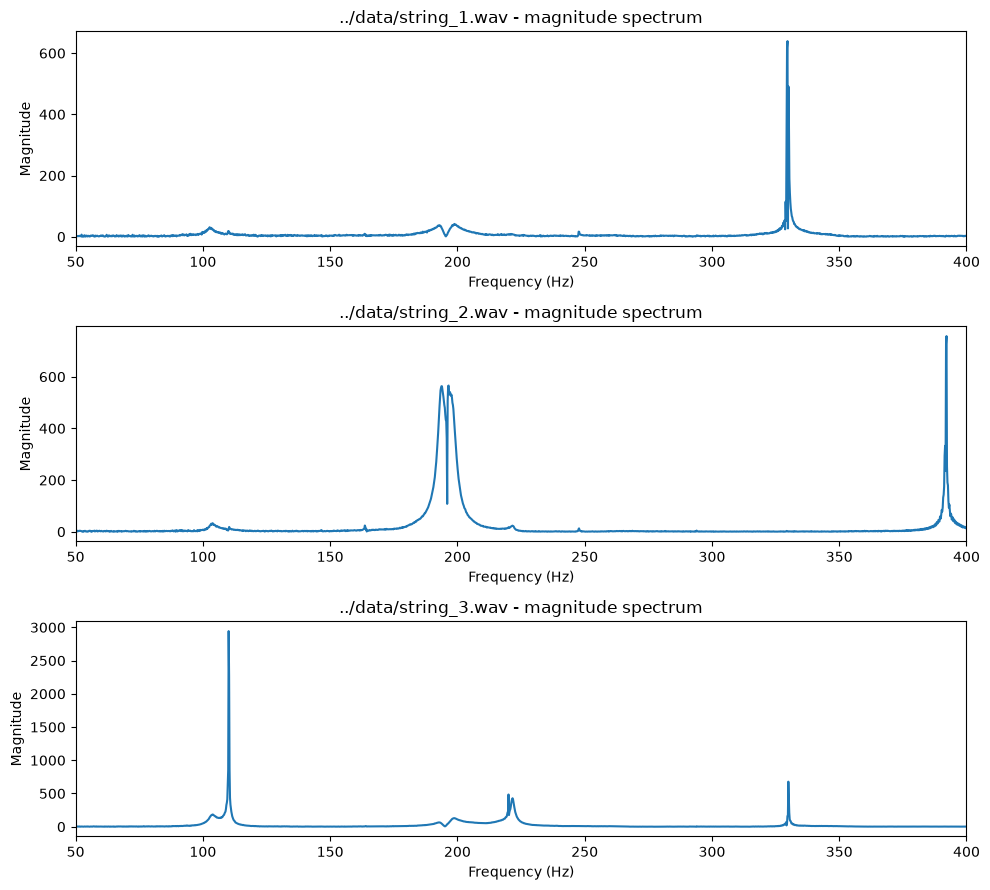

In [28]:
spectra = {}

fig, axes = plt.subplots(len(FILES), 1, figsize=(10, 3 * len(FILES)))

for i, f in enumerate(FILES):
    sr, data = signals[f]
    spectrum = np.abs(fftshift(fft(data)))
    freqs = fftshift(fftfreq(len(data), 1 / sr))
    spectra[f] = (freqs, spectrum)

    axes[i].plot(freqs, spectrum)
    axes[i].set_xlim(50, 400)
    axes[i].set_title(f"{f} - magnitude spectrum")
    axes[i].set_xlabel("Frequency (Hz)")
    axes[i].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

## Find the fundamental and the note

Taking the tallest peak can pick a harmonic (for exemple : a string's 2nd or 3rd harmonic can be louder). Since the fundamental is the lowest-frequency peak, we instead take the lowest significant peak (above 20% of the max) and also which is actually a "reasonable" choice (in guitar range from 60 to 400HZ).

In [29]:
from scipy.signal import find_peaks


def detect_fundamental(freqs, spectrum, fmin=60, fmax=400):
    guitar_range = (freqs >= fmin) & (freqs <= fmax)
    freqs_r, spec_r = freqs[guitar_range], spectrum[guitar_range]
    df = freqs[1] - freqs[0]
    peaks, _ = find_peaks(spec_r, height=0.2 * spec_r.max(), distance=int(5 / df))
    return freqs_r[peaks[0]], freqs_r[peaks]


def closest_note(freq, note_freqs):
    note, ref_freq = min(note_freqs.items(), key=lambda kv: abs(freq - kv[1]))
    cents = 1200 * np.log2(freq / ref_freq)
    return note, ref_freq, cents


for f in FILES:
    freqs, spectrum = spectra[f]
    f0, all_peaks = detect_fundamental(freqs, spectrum)
    note, ref_freq, cents = closest_note(f0, NOTE_FREQS)
    print(f"{f}: peaks at {np.round(all_peaks, 1)} Hz with the fundamental being = {f0:.2f} Hz. {note} ({cents:+.2f} cents)")

../data/string_1.wav: peaks at [329.7] Hz with the fundamental being = 329.68 Hz. Thus, E1 (+0.27 cents)
../data/string_2.wav: peaks at [196.5 392.1] Hz with the fundamental being = 196.54 Hz. Thus, G3 (+4.77 cents)
../data/string_3.wav: peaks at [110.1 330. ] Hz with the fundamental being = 110.12 Hz. Thus, A5 (+1.92 cents)


Every note is within 5 cents of the target frequency. But String 2 is at +4.77 cents, which is a bit high.

## Method 2: tallest peak = K × fundamental

The tallest peak is always a harmonic K × f0 (K = 1, 2, 3...). We use the lowest peak above to find K, then divide the tallest peak by K. Its error in Hz is divided by K too, so the estimate is more precise. It will search for the K automatically

In [38]:
def detect_fundamental_with_k(freqs, spectrum, fmin=60, fmax=400):
    guitar_range = (freqs >= fmin) & (freqs <= fmax)
    freqs_r, spec_r = freqs[guitar_range], spectrum[guitar_range]
    df = freqs[1] - freqs[0]
    peaks, _ = find_peaks(spec_r, height=0.2 * spec_r.max(), distance=int(5 / df))
    
    f_rough = freqs_r[peaks[0]]
    f_tall = freqs_r[peaks[np.argmax(spec_r[peaks])]]

    K = round(f_tall / f_rough)

    return f_tall / K, K


for f in FILES:
    freqs, spectrum = spectra[f]
    f0, K = detect_fundamental_with_k(freqs, spectrum)
    note, ref_freq, cents = closest_note(f0, NOTE_FREQS)
    print(f"{f}: K = {K} -> fundamental = {f0:.2f} Hz -> {note} ({cents:+.2f} cents)")

../data/string_1.wav: K = 1 -> fundamental = 329.68 Hz -> E1 (+0.27 cents)
../data/string_2.wav: K = 2 -> fundamental = 196.07 Hz -> G3 (+0.65 cents)
../data/string_3.wav: K = 1 -> fundamental = 110.12 Hz -> A5 (+1.92 cents)


## Method 3: Harmonic Product Spectrum (HPS)

For each candidate frequency f, we multiply the spectrum values at f, 2f, 3f, 4f, 5f (read with `np.interp`, so f can be any value, not only an FFT bin). The true fundamental has a peak at all its harmonics, so its product is the biggest.

In [37]:
def detect_fundamental_hps(freqs, spectrum, n_harmonics=5, fmin=60, fmax=400):
    candidates = np.arange(fmin, fmax, 0.01)
    hps = np.ones_like(candidates)
    for h in range(1, n_harmonics + 1):
        hps *= np.interp(h * candidates, freqs, spectrum)
    return candidates[np.argmax(hps)]


for f in FILES:
    freqs, spectrum = spectra[f]
    f0 = detect_fundamental_hps(freqs, spectrum)
    note, ref_freq, cents = closest_note(f0, NOTE_FREQS)
    print(f"{f}: fundamental = {f0:.2f} Hz -> {note} ({cents:+.2f} cents)")

../data/string_1.wav: fundamental = 329.61 Hz -> E1 (-0.11 cents)
../data/string_2.wav: fundamental = 196.04 Hz -> G3 (+0.35 cents)
../data/string_3.wav: fundamental = 110.04 Hz -> A5 (+0.63 cents)


## Conclusion

| String | Note | 1. Lowest peak | 2. Tallest peak / K | 3. HPS |
|---|---|---|---|---|
| 1 | E1 | +0.27 cents | +0.27 cents | -0.11 cents |
| 2 | G3 | +4.77 cents | +0.65 cents | +0.35 cents |
| 3 | A5 | +1.92 cents | +1.92 cents | +0.63 cents |

The three methods find the same notes. On string 2 the tallest peak is the 2nd harmonic (K = 2), so dividing by K, the error goes from +4.77 to +0.65 cents. HPS gives the smallest deviations overall (all under 1 cent), so all three strings are very well tuned !